In [38]:
# Route Optimization using OR-tools + Static Matplotlib Route Plot

#---IMPORTS---

import os
import pickle
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from ortools.constraint_solver.pywrapcp import RoutingIndexManager, RoutingModel
from ortools.constraint_solver import routing_enums_pb2


In [39]:
print("Current working directory:", os.getcwd())
print("\nFolders and files inside routing:")
for item in os.listdir():
    print(item)

Current working directory: /home/ridwan-ayinde/Desktop/MIT Emerging Talent/Final Project/4_data_analysis/routing

Folders and files inside routing:
04_clustering_and_zones.ipynb
03_route_generation.ipynb
05_evaluation.ipynb
data
02_shortest_paths.ipynb
01_build_graph.ipynb


In [40]:
from ortools.constraint_solver import pywrapcp

data_path = "data"

#Load graph
graph_file = os.path.join(data_path, "road_graph.pkl")
with open(graph_file, "rb") as f:
    G = pickle.load(f)

# Load POIs
pois_file = os.path.join(data_path, "pois_largest_component.geojson")
pois = gpd.read_file(pois_file)



# Load distance matrix
dist_file = os.path.join(data_path, "full_poi_distances.csv")
dist_matrix_df = pd.read_csv(dist_file, index_col=0)
dist_matrix = dist_matrix_df.values


print("Graph nodes:", len(G.nodes))
print("POIs:", len(pois))
print("Distance matrix shape:", dist_matrix.shape)

Graph nodes: 15248
POIs: 140
Distance matrix shape: (140, 140)


In [41]:
# Build OR-Tools Routing Model

n_nodes = dist_matrix.shape[0]

# Create manager: 1 vehicle, depot = 0

manager = RoutingIndexManager (n_nodes, 1, 0)
routing = RoutingModel(manager)

# Cost function using distance matrix
def distance_callback(from_index, to_index):
    f = manager.IndexToNode(from_index)
    t = manager.IndexToNode (to_index)
    return int (dist_matrix[f][t])

transit_callback_idx = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles (transit_callback_idx)



search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_params.time_limit.seconds = 5

# Solve
task_solution = routing.SolveWithParameters(search_params)
print ("Solved:", task_solution is not None)

Solved: True


In [42]:
def extract_route (manager, routing, solution):
    idx = routing.Start(0)
    route = []
    while not routing.IsEnd(idx):
        node = manager.IndexToNode(idx)
        route.append(node)
        idx = solution.Value(routing.NextVar(idx))
    route.append (manager.IndexToNode(idx))
    return route

route_order = extract_route(manager, routing, task_solution)
print ("Route order (by POI index):")
print (route_order)

# Save route

pd.to_pickle (route_order, os.path.join (data_path, "route_order.pkl"))

Route order (by POI index):
[0, 31, 32, 125, 65, 85, 132, 120, 121, 122, 136, 123, 69, 66, 67, 76, 138, 77, 107, 134, 133, 113, 112, 117, 111, 83, 115, 116, 84, 71, 129, 128, 114, 127, 101, 100, 102, 103, 73, 74, 75, 93, 94, 95, 72, 79, 80, 82, 96, 81, 97, 86, 87, 88, 89, 137, 90, 91, 92, 99, 98, 78, 109, 110, 108, 139, 135, 68, 131, 119, 118, 124, 70, 130, 104, 126, 105, 106, 42, 1, 41, 60, 59, 49, 21, 20, 4, 5, 52, 37, 38, 39, 6, 51, 36, 48, 44, 29, 45, 46, 43, 47, 50, 57, 33, 35, 34, 55, 56, 54, 7, 11, 62, 19, 10, 61, 63, 25, 53, 26, 64, 15, 17, 16, 18, 27, 9, 14, 13, 12, 23, 22, 24, 8, 28, 2, 3, 58, 40, 30, 0]


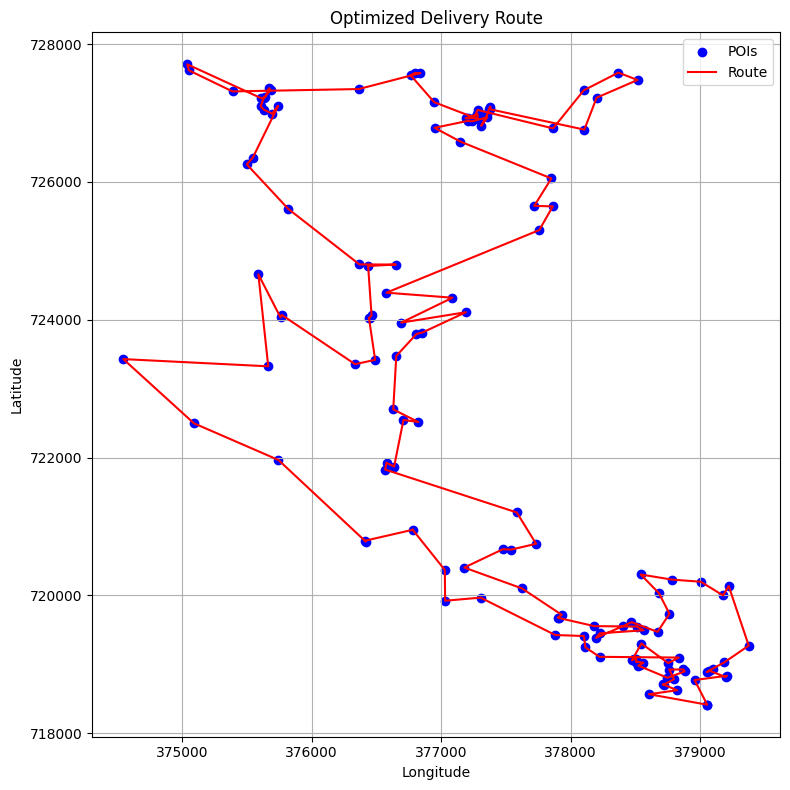

In [43]:
# Visualize Route (Static Plot for GitHub)

# Get node coordinates from POIs

coords = [(pois.iloc[i].geometry.x, pois.iloc[i].geometry.y) for i in range (len (pois))]

# Prepare route coordinate sequence

route_coords = [coords[i] for i in route_order]

# Plot
plt.figure (figsize=(8, 8))

#Plot all POIs

xs, ys = zip(*coords)
plt.scatter(xs, ys, color ='blue', label='POIs')

# Plot the route path

rx, ry = zip(*route_coords)
plt.plot(rx, ry, color='red', label ='Route')

plt.title ("Optimized Delivery Route")
plt.xlabel ("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



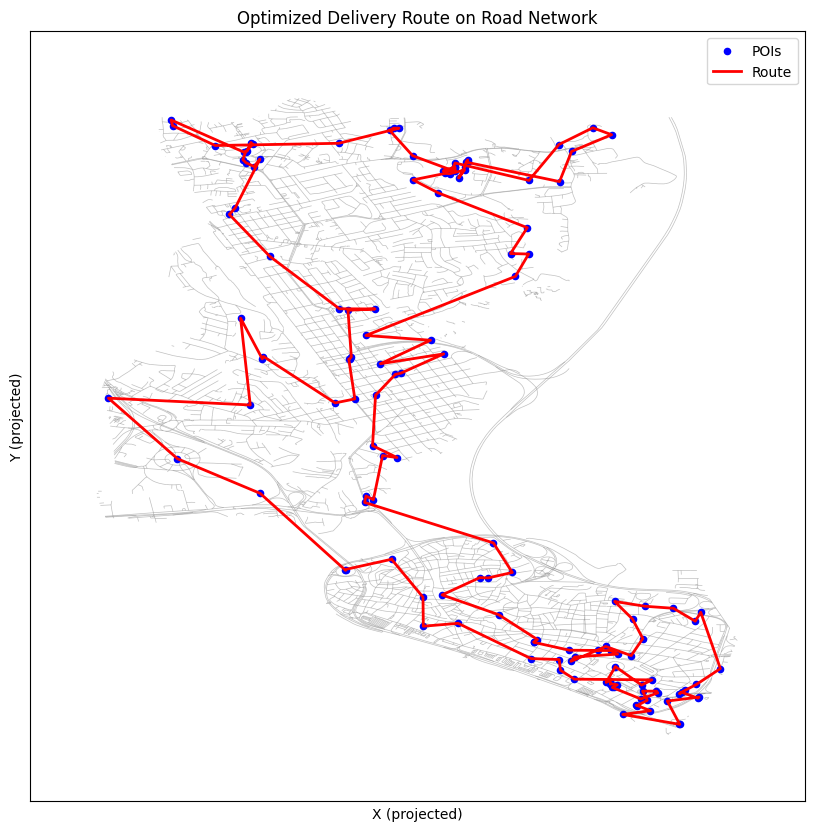

In [44]:
import matplotlib.pyplot as plt

# Positions are the node IDs themselves
pos = {node: node for node in G.nodes()}

plt.figure(figsize=(10, 10))

# Plot edges (roads)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, width=0.5)

# Plot POIs
xs, ys = zip(*coords)
plt.scatter(xs, ys, color='blue', s=20, label='POIs')

# Plot route
rx, ry = zip(*route_coords)
plt.plot(rx, ry, color='red', linewidth=2, label='Route')

plt.title("Optimized Delivery Route on Road Network")
plt.xlabel("X (projected)")
plt.ylabel("Y (projected)")
plt.legend()
plt.show()




